# 06 - MLflow Model Registry & Monitoring

**Objective:** Extend MLflow from experiment tracking into production — register models in the
Model Registry, manage versions through staging/production transitions, and build a monitoring
pipeline that detects data drift and model degradation using the breast cancer data injection system.

**Concepts Covered:**
- MLflow Tracking Deep-Dive (MlflowClient, programmatic comparison)
- MLflow Model Registry (registration, versioning, stage transitions)
- Population Stability Index (PSI) for prediction drift
- Feature distribution drift (Kolmogorov-Smirnov test)
- Schema drift detection at inference time
- Champion/Challenger deployment pattern
- Automated monitoring loop concept

> **Prerequisite:** This notebook builds on the models trained in `05_model_tuning_validation_comparison.ipynb`.
> It is designed to work with `breast_cancer_copy` (the reference implementation).

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import json
import datetime
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from scipy.stats import ks_2samp

import mlflow
from mlflow.tracking import MlflowClient
import mlflow.sklearn

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("All imports successful")

All imports successful


In [2]:
# Add project root to path so we can import project modules
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from config import MLFLOW_TRACKING_URI, MLFLOW_EXPERIMENT, DATA_DIR, PROCESSED_DIR, get_logger
from models.train import train_all, train_logistic, train_xgboost, train_random_forest, train_svm, save_model
from models.predict import load_model, predict, predict_proba

logger = get_logger(__name__)
print(f"Project root: {PROJECT_ROOT}")
print(f"MLflow tracking URI: {MLFLOW_TRACKING_URI}")
print(f"MLflow experiment: {MLFLOW_EXPERIMENT}")

Project root: /home/bioinf/Desktop/PERSONAL_WORK/RUMOS/MLengi/hidden_projet/breast_cancer_copy
MLflow tracking URI: /home/bioinf/Desktop/PERSONAL_WORK/RUMOS/MLengi/hidden_projet/breast_cancer_copy/mlflow_artifacts
MLflow experiment: breast_cancer_ml


In [3]:
PROCESSED_DIR = Path(PROJECT_ROOT / "data" / "processed")
MODELS_DIR = Path(PROJECT_ROOT / "models")

df = pd.read_csv(PROCESSED_DIR / "clean_data.csv")
X = df.drop(columns=["Diagnosis"])
y = df["Diagnosis"]
FEATURE_NAMES = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save scaler for later use in monitoring
scaler_path = MODELS_DIR / "scaler_monitoring.joblib"
joblib.dump(scaler, scaler_path)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Class balance:\n{y_train.value_counts(normalize=True)}")

Train: (455, 30), Test: (114, 30)
Class balance:
Diagnosis
0    0.626374
1    0.373626
Name: proportion, dtype: float64


---
## Section 1: Train & Log Models with MLflow

Before we can use the Model Registry, we need models to register. We'll train the 4 standard
classifiers (LogisticRegression, RandomForest, XGBoost, SVM) and log each one as an MLflow run
with its model artifact. This creates the experiment history we'll query in the next section.

> Note: LogisticRegression and SVM use **scaled** features; tree-based models use raw features.

In [4]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("breast_cancer_06_registry")

model_configs = [
    ("LogisticRegression", train_logistic, X_train_scaled, X_test_scaled),
    ("RandomForest", train_random_forest, X_train, X_test),
    ("XGBoost", train_xgboost, X_train, X_test),
    ("SVM", train_svm, X_train_scaled, X_test_scaled),
]

run_ids = {}
metrics_dict = {}

for name, train_fn, X_tr, X_te in model_configs:
    model = train_fn(X_tr, y_train)
    y_pred = model.predict(X_te)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    with mlflow.start_run(run_name=name) as run:
        mlflow.log_param("model_type", name)
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("precision", prec)
        mlflow.log_metric("recall", rec)
        mlflow.log_metric("f1", f1)
        mlflow.sklearn.log_model(model, "model")

        run_ids[name] = run.info.run_id
        metrics_dict[name] = {"accuracy": acc, "f1": f1}

    print(f"{name:20s}  acc={acc:.4f}  f1={f1:.4f}  run_id={run.info.run_id[:12]}...")

# Also log the scaler as a project artifact
mlflow.log_artifact(str(scaler_path))

baseline_acc = metrics_dict[list(metrics_dict.keys())[0]]["accuracy"]
print(f"\nBaseline accuracy (reference for drift): {baseline_acc:.4f}")

2026-05-12 13:16:20,748 - models.train - INFO - Logistic Regression trained
2026/05/12 13:16:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 13:16:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026-05-12 13:16:23,147 - models.train - INFO - Random Forest trained
2026/05/12 13:16:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 13:16:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code 

LogisticRegression    acc=0.9649  f1=0.9512  run_id=0646d96255a3...


2026-05-12 13:16:25,269 - models.train - INFO - XGBoost trained


RandomForest          acc=0.9737  f1=0.9630  run_id=1905b956efc7...


2026/05/12 13:16:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 13:16:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026-05-12 13:16:27,313 - models.train - INFO - SVM trained
2026/05/12 13:16:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 13:16:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For mo

XGBoost               acc=0.9737  f1=0.9630  run_id=9b27466ee5f7...
SVM                   acc=0.9737  f1=0.9630  run_id=b00adc24365f...

Baseline accuracy (reference for drift): 0.9649


---
## Section 2: MLflow Tracking Deep-Dive

The MLflow Tracking UI is great for visual exploration, but when you need to compare runs
programmatically — for example, to find the best model across 100 trials — you use the
`MlflowClient` API. This section shows how to query experiments, extract runs into a DataFrame,
and compare results programmatically.

In [5]:
client = MlflowClient(tracking_uri=MLFLOW_TRACKING_URI)

experiment = client.get_experiment_by_name("breast_cancer_06_registry")
runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.f1 DESC"]
)

print(f"Found {len(runs)} runs in experiment '{experiment.name}'\n")
for run in runs:
    name = run.data.tags.get("mlflow.runName", "unnamed")
    acc = run.data.metrics.get("accuracy", 0)
    f1 = run.data.metrics.get("f1", 0)
    prec = run.data.metrics.get("precision", 0)
    rec = run.data.metrics.get("recall", 0)
    print(f"  {name:20s}  acc={acc:.4f}  prec={prec:.4f}  rec={rec:.4f}  f1={f1:.4f}")

Found 15 runs in experiment 'breast_cancer_06_registry'

  SVM                   acc=0.9737  prec=1.0000  rec=0.9286  f1=0.9630
  XGBoost               acc=0.9737  prec=1.0000  rec=0.9286  f1=0.9630
  RandomForest          acc=0.9737  prec=1.0000  rec=0.9286  f1=0.9630
  SVM                   acc=0.9737  prec=1.0000  rec=0.9286  f1=0.9630
  XGBoost               acc=0.9737  prec=1.0000  rec=0.9286  f1=0.9630
  RandomForest          acc=0.9737  prec=1.0000  rec=0.9286  f1=0.9630
  SVM                   acc=0.9737  prec=1.0000  rec=0.9286  f1=0.9630
  XGBoost               acc=0.9737  prec=1.0000  rec=0.9286  f1=0.9630
  RandomForest          acc=0.9737  prec=1.0000  rec=0.9286  f1=0.9630
  LogisticRegression    acc=0.9649  prec=0.9750  rec=0.9286  f1=0.9512
  LogisticRegression    acc=0.9649  prec=0.9750  rec=0.9286  f1=0.9512
  LogisticRegression    acc=0.9649  prec=0.9750  rec=0.9286  f1=0.9512
  aged-goat-158         acc=0.0000  prec=0.0000  rec=0.0000  f1=0.0000
  wise-lynx-224     

,model,accuracy,precision,recall,f1,run_id
0,SVM,0.9737,1.000,0.9286,0.9630,b00adc24365f4f3fa6531abdd7a171ff
1,XGBoost,0.9737,1.000,0.9286,0.9630,9b27466ee5f743e19baa00c03ca39298
2,RandomForest,0.9737,1.000,0.9286,0.9630,1905b956efc74cff8df91f5f24a66b15
3,SVM,0.9737,1.000,0.9286,0.9630,b3b385a7254c48e4a0cb49e428735d8a
4,XGBoost,0.9737,1.000,0.9286,0.9630,8c5b1418474a4e6e8961a6ef61ee1bbb
5,RandomForest,0.9737,1.000,0.9286,0.9630,ae60113ebf7f4e4e851012c86e2f6ff4
6,SVM,0.9737,1.000,0.9286,0.9630,61479fc1809a4ca083b68fab77b32236
7,XGBoost,0.9737,1.000,0.9286,0.9630,d3d611433c00445789f70728de930d8d
8,RandomForest,0.9737,1.000,0.9286,0.9630,12e790fc65c34690b0f2afb0629bad7e
9,LogisticRegression,0.9649,0.975,0.9286,0.9512,0646d96255a34e9e8182c90a9d4ea72a


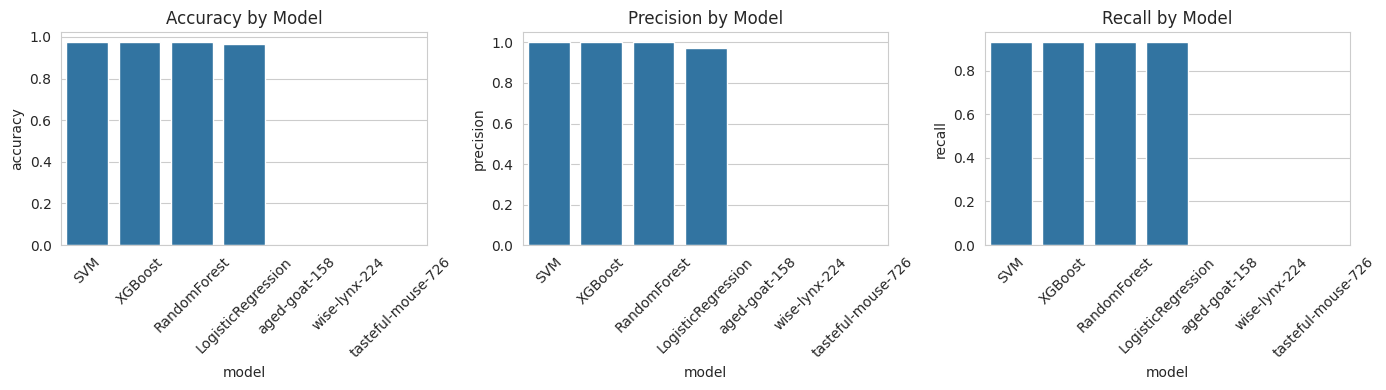

In [6]:
rows = []
for run in runs:
    rows.append({
        "model": run.data.tags.get("mlflow.runName", "unnamed"),
        "accuracy": run.data.metrics.get("accuracy", 0),
        "precision": run.data.metrics.get("precision", 0),
        "recall": run.data.metrics.get("recall", 0),
        "f1": run.data.metrics.get("f1", 0),
        "run_id": run.info.run_id,
    })

results_df = pd.DataFrame(rows)
display(results_df.round(4))

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, metric in enumerate(["accuracy", "precision", "recall"]):
    sns.barplot(data=results_df, x="model", y=metric, ax=axes[i])
    axes[i].set_title(f"{metric.capitalize()} by Model")
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
plt.tight_layout()
plt.show()

---
## Section 3: MLflow Model Registry

The **Model Registry** adds a layer on top of Tracking. It lets you:
- Group related models under a single **registered model name**
- Assign **versions** (v1, v2, v3, ...) to each registered model
- Transition versions through **stages**: `None → Staging → Production → Archived`
- Load models by stage alias (e.g. `models:/breast_cancer_classifier/Production`)

This is the foundation of a model deployment pipeline.

In [7]:
REGISTERED_MODEL_NAME = "breast_cancer_classifier"

registered_versions = {}
for name, run_id in run_ids.items():
    model_uri = f"runs:/{run_id}/model"
    result = mlflow.register_model(model_uri, REGISTERED_MODEL_NAME)
    registered_versions[name] = result.version
    print(f"  Registered {name:20s} → version {result.version}")

Registered model 'breast_cancer_classifier' already exists. Creating a new version of this model...
2026/05/12 13:16:29 WARNING mlflow.tracking._model_registry.fluent: Run with id 0646d96255a34e9e8182c90a9d4ea72a has no artifacts at artifact path 'model', registering model based on models:/m-34f4226c3c664a989f4c1748db704cb9 instead
Created version '11' of model 'breast_cancer_classifier'.
Registered model 'breast_cancer_classifier' already exists. Creating a new version of this model...
2026/05/12 13:16:29 WARNING mlflow.tracking._model_registry.fluent: Run with id 1905b956efc74cff8df91f5f24a66b15 has no artifacts at artifact path 'model', registering model based on models:/m-e4f3799e001842fb8d3da56a240e6879 instead
Created version '12' of model 'breast_cancer_classifier'.
Registered model 'breast_cancer_classifier' already exists. Creating a new version of this model...
2026/05/12 13:16:29 WARNING mlflow.tracking._model_registry.fluent: Run with id 9b27466ee5f743e19baa00c03ca39298 has

  Registered LogisticRegression   → version 11
  Registered RandomForest         → version 12
  Registered XGBoost              → version 13
  Registered SVM                  → version 14


Created version '14' of model 'breast_cancer_classifier'.


In [8]:
# Inspect all versions
versions = client.search_model_versions(f"name='{REGISTERED_MODEL_NAME}'")
for v in sorted(versions, key=lambda x: int(x.version)):
    print(f"  Version {v.version}: run_id={v.run_id[:12]}...  stage={v.current_stage}")

  Version 1: run_id=c0f6fdb88b3e...  stage=Archived
  Version 2: run_id=12e790fc65c3...  stage=Archived
  Version 3: run_id=d3d611433c00...  stage=Staging
  Version 4: run_id=61479fc1809a...  stage=Production
  Version 5: run_id=0b07c2aa8301...  stage=Staging
  Version 6: run_id=67511e553e05...  stage=Archived
  Version 7: run_id=ae60113ebf7f...  stage=Archived
  Version 8: run_id=8c5b1418474a...  stage=Staging
  Version 9: run_id=b3b385a7254c...  stage=Production
  Version 10: run_id=1fe8df7663e2...  stage=Staging
  Version 11: run_id=0646d96255a3...  stage=None
  Version 12: run_id=1905b956efc7...  stage=None
  Version 13: run_id=9b27466ee5f7...  stage=None
  Version 14: run_id=b00adc24365f...  stage=None


In [9]:
# Map run_id → version for the sorted runs
run_to_version = {v.run_id: v for v in versions}

# Best (highest F1) → Production
best_run = runs[0]
best_version = run_to_version[best_run.info.run_id]
client.transition_model_version_stage(
    name=REGISTERED_MODEL_NAME,
    version=best_version.version,
    stage="Production"
)
print(f"Version {best_version.version} ({best_run.data.tags['mlflow.runName']}) → Production")

# Second best → Staging
if len(runs) > 1:
    second_run = runs[1]
    second_version = run_to_version[second_run.info.run_id]
    client.transition_model_version_stage(
        name=REGISTERED_MODEL_NAME,
        version=second_version.version,
        stage="Staging"
    )
    print(f"Version {second_version.version} ({second_run.data.tags['mlflow.runName']}) → Staging")
# Re-fetch versions to get updated stages
versions = client.search_model_versions(f"name='{REGISTERED_MODEL_NAME}'")

# Archive remaining
for v in versions:
    if v.current_stage not in ("Production", "Staging"):
        client.transition_model_version_stage(
            name=REGISTERED_MODEL_NAME,
            version=v.version,
            stage="Archived"
        )
        print(f"Version {v.version} → Archived")

print("\nFinal stage assignments:")
versions = client.search_model_versions(f"name='{REGISTERED_MODEL_NAME}'")
for v in sorted(versions, key=lambda x: int(x.version)):
    print(f"  Version {v.version}: stage={v.current_stage}")

Version 14 (SVM) → Production
Version 13 (XGBoost) → Staging
Version 12 → Archived
Version 11 → Archived
Version 2 → Archived
Version 1 → Archived
Version 6 → Archived
Version 7 → Archived

Final stage assignments:
  Version 1: stage=Archived
  Version 2: stage=Archived
  Version 3: stage=Staging
  Version 4: stage=Production
  Version 5: stage=Staging
  Version 6: stage=Archived
  Version 7: stage=Archived
  Version 8: stage=Staging
  Version 9: stage=Production
  Version 10: stage=Staging
  Version 11: stage=Archived
  Version 12: stage=Archived
  Version 13: stage=Staging
  Version 14: stage=Production


In [10]:
# Load production model by version number
# (Note: stage aliases like /Production require a database-backed MLflow backend;
#  with file-based tracking, use explicit version numbers)
PRODUCTION_VERSION = best_version.version  # defined in previous cell
prod_model = mlflow.sklearn.load_model(
    model_uri=f"models:/{REGISTERED_MODEL_NAME}/{PRODUCTION_VERSION}"
)

# Determine if this model needs scaling (check if it's LR or SVM)
# We'll assume scaling is always safe and apply it
y_pred_prod = prod_model.predict(X_test_scaled)
prod_acc = accuracy_score(y_test, y_pred_prod)
print(f"Production model (v{PRODUCTION_VERSION}) accuracy: {prod_acc:.4f}")

# Also get probabilities for PSI computation later
ref_proba = prod_model.predict_proba(X_test_scaled)[:, 1]
ref_accuracy = prod_acc

# Load Staging model if it exists
try:
    STAGING_VERSION = second_version.version
    stg_model = mlflow.sklearn.load_model(
    model_uri=f"models:/{REGISTERED_MODEL_NAME}/{STAGING_VERSION}"
    )
    y_pred_stg = stg_model.predict(X_test_scaled)
    stg_acc = accuracy_score(y_test, y_pred_stg)
    print(f"Staging  model (v{STAGING_VERSION}) accuracy: {stg_acc:.4f}")
except Exception:
    print("Staging model could not be loaded (may not exist if only 1 run)")


Production model (v14) accuracy: 0.9737
Staging  model (v13) accuracy: 0.6316


---
## Section 4: Simulated Monitoring — Data Drift Detection

In production, data distributions can shift over time. This is called **data drift** (or
covariate shift), and it can silently degrade model performance. The breast cancer project
includes a `data_injection` system that simulates real-world failure modes.

We'll load the Production model and evaluate it against 7 corrupted variants of the data,
tracking:
- **Accuracy drop**: how much performance degrades
- **PSI (Population Stability Index)**: a measure of prediction distribution shift
- **KS-test**: per-feature distribution comparison between clean and corrupted data

In [11]:
CORRUPTED_DIR = PROCESSED_DIR / "corrupted"

preset_names = ["missing_light", "missing_heavy", "noise_low", "noise_high",
                "outliers", "bias", "schema_drift"]

corrupted_data = {}
for preset in preset_names:
    path = CORRUPTED_DIR / f"corrupted_{preset}.csv"
    corrupted_data[preset] = pd.read_csv(path)
    print(f"{preset:20s}: {corrupted_data[preset].shape}")



missing_light       : (569, 31)
missing_heavy       : (569, 31)
noise_low           : (569, 31)
noise_high          : (569, 31)
outliers            : (569, 31)
bias                : (569, 31)
schema_drift        : (569, 31)


In [12]:
def compute_psi(expected, actual, bins=10):
    """
    Population Stability Index.
    PSI < 0.1   → no significant drift
    0.1 ≤ PSI < 0.25 → moderate drift (investigate)
    PSI ≥ 0.25  → severe drift (retrain needed)
    """
    expected = np.clip(expected, 0.001, 0.999)
    actual = np.clip(actual, 0.001, 0.999)

    breaks = np.linspace(0, 1, bins + 1)
    expected_percents = np.histogram(expected, breaks)[0] / len(expected)
    actual_percents = np.histogram(actual, breaks)[0] / len(actual)

    expected_percents = np.where(expected_percents == 0, 0.001, expected_percents)
    actual_percents = np.where(actual_percents == 0, 0.001, actual_percents)

    psi = np.sum((actual_percents - expected_percents) * np.log(actual_percents / expected_percents))
    return psi


def compute_feature_drift(ref_df, corr_df, columns=None, max_cols=5):
    """Compute KS-statistic for each feature. Returns drift dict."""
    if columns is None:
        columns = ref_df.select_dtypes(include=[np.number]).columns[:max_cols]
    drifts = {}
    for col in columns:
        if col in corr_df.columns:
            stat, pval = ks_2samp(ref_df[col].dropna(), corr_df[col].dropna())
            drifts[col] = {"ks_stat": stat, "p_value": pval}
    return drifts

In [15]:
mlflow.set_experiment("breast_cancer_06_monitoring")

monitoring_results = []

for preset, corr_df in corrupted_data.items():
    print(f"Evaluating preset: {preset}")
    with mlflow.start_run(run_name=f"monitoring_{preset}") as run:
        mlflow.log_param("preset", preset)

        try:
            # Attempt to extract features and target
            if "Diagnosis" in corr_df.columns:
                X_corr = corr_df.drop(columns=["Diagnosis"])
                y_corr = corr_df["Diagnosis"]
            elif "target_Diagnosis" in corr_df.columns:
                # Schema drift: target column renamed
                X_corr = corr_df.drop(columns=["target_Diagnosis"])
                y_corr = corr_df["target_Diagnosis"]
                mlflow.log_param("schema_drift", True)
            elif "diagnosis_label" in corr_df.columns:
                # Schema drift: target column renamed
                X_corr = corr_df.drop(columns=["diagnosis_label"])
                y_corr = corr_df["diagnosis_label"]
                mlflow.log_param("schema_drift", True)
            else:
                raise KeyError(f"Unknown target column in {preset}: {corr_df.columns.tolist()}")

            # Check for missing expected feature columns
            missing_cols = set(FEATURE_NAMES) - set(X_corr.columns)
            extra_cols = set(X_corr.columns) - set(FEATURE_NAMES)
            if missing_cols:
                mlflow.log_param("missing_features", str(missing_cols))
                print(f"  [{preset}] Missing columns: {missing_cols}, filling with 0")
                for col in missing_cols:
                    X_corr[col] = 0.0
            if extra_cols:
                X_corr = X_corr.drop(columns=list(extra_cols))

            # Ensure correct column order
            X_corr = X_corr[FEATURE_NAMES]

            # Handle NaN by dropping rows with NaN target
            valid = y_corr.notna()
            if valid.sum() < len(valid):
                mlflow.log_metric("nan_target_ratio", float((~valid).sum() / len(valid)))
                print(f"  [{preset}] Dropping {(~valid).sum()} rows with NaN target")
                X_corr = X_corr[valid]
                y_corr = y_corr[valid]
            y_corr = (y_corr > 0.5).astype(int)

            # Scale
            X_corr_scaled = scaler.transform(X_corr)

            # Predict
            y_pred = prod_model.predict(X_corr_scaled)
            proba = prod_model.predict_proba(X_corr_scaled)[:, 1]

            # Metrics
            acc = accuracy_score(y_corr, y_pred)
            f1 = f1_score(y_corr, y_pred)
            acc_drop = ref_accuracy - acc
            psi = compute_psi(ref_proba, proba)

            # Feature drift (first 5 numeric features)
            feature_drift = compute_feature_drift(X_test, X_corr, max_cols=5)
            avg_ks = np.mean([v["ks_stat"] for v in feature_drift.values()]) if feature_drift else 0.0

            # Log to MLflow
            mlflow.log_metric("accuracy", acc)
            mlflow.log_metric("f1", f1)
            mlflow.log_metric("accuracy_drop", acc_drop)
            mlflow.log_metric("psi", psi)
            mlflow.log_metric("avg_ks_stat", avg_ks)

            monitoring_results.append({
                "preset": preset,
                "accuracy": acc,
                "f1": f1,
                "accuracy_drop": acc_drop,
                "psi": psi,
                "avg_ks_stat": avg_ks,
            })

            print(f"  {preset:20s}  acc={acc:.4f}  drop={acc_drop:.4f}  psi={psi:.4f}")
            

        except Exception as e:
            import traceback
            traceback.print_exc()
            print(f"  {preset:20s}  ERROR: {e}")
            mlflow.log_param("error", str(e))
        mlflow.end_run()

Evaluating preset: missing_light
  [missing_light] Dropping 28 rows with NaN target
  missing_light         acc=0.9852  drop=-0.0115  psi=0.0598
Evaluating preset: missing_heavy
  [missing_heavy] Dropping 113 rows with NaN target
  missing_heavy         acc=0.9868  drop=-0.0132  psi=0.0664
Evaluating preset: noise_low
  noise_low             acc=0.9824  drop=-0.0087  psi=0.0906
Evaluating preset: noise_high
  noise_high            acc=0.9807  drop=-0.0070  psi=0.1357
Evaluating preset: outliers
  outliers              acc=0.9543  drop=0.0194  psi=0.1026
Evaluating preset: bias
  bias                  acc=0.9807  drop=-0.0070  psi=0.0979
Evaluating preset: schema_drift
  schema_drift          acc=0.9842  drop=-0.0105  psi=0.0667


,preset,accuracy,f1,accuracy_drop,psi,avg_ks_stat
0,missing_light,0.9852,0.9797,-0.0115,0.0598,0.0579
1,missing_heavy,0.9868,0.9820,-0.0132,0.0664,0.0596
2,noise_low,0.9824,0.9758,-0.0087,0.0906,0.0592
3,noise_high,0.9807,0.9735,-0.0070,0.1357,0.0729
4,outliers,0.9543,0.9398,0.0194,0.1026,0.0640
5,bias,0.9807,0.9734,-0.0070,0.0979,0.1106
6,schema_drift,0.9842,0.9783,-0.0105,0.0667,0.0566


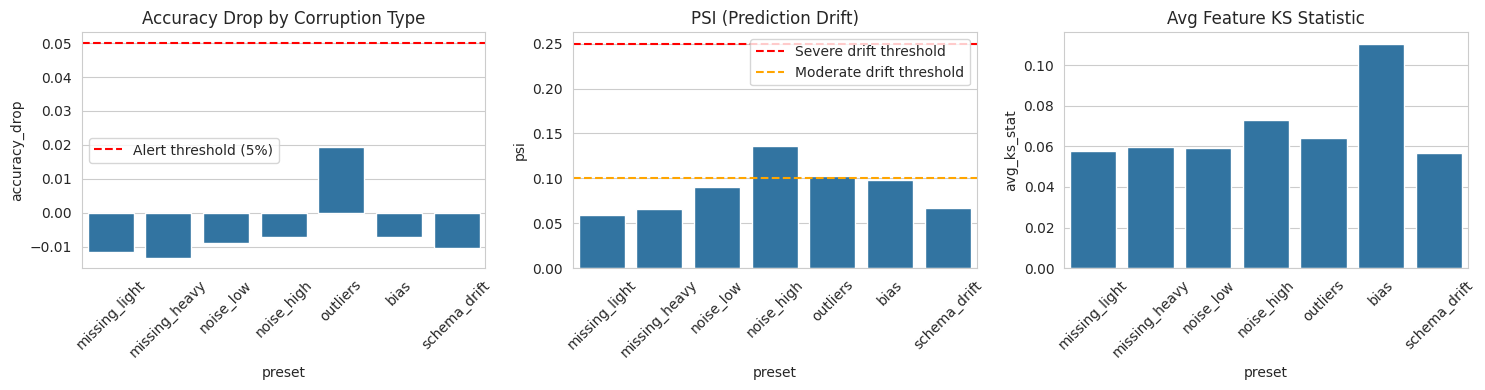

In [16]:
mon_df = pd.DataFrame(monitoring_results)
display(mon_df.round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(data=mon_df, x="preset", y="accuracy_drop", ax=axes[0])
axes[0].set_title("Accuracy Drop by Corruption Type")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
axes[0].axhline(y=0.05, color="r", linestyle="--", label="Alert threshold (5%)")
axes[0].legend()

sns.barplot(data=mon_df, x="preset", y="psi", ax=axes[1])
axes[1].set_title("PSI (Prediction Drift)")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
axes[1].axhline(y=0.25, color="r", linestyle="--", label="Severe drift threshold")
axes[1].axhline(y=0.1, color="orange", linestyle="--", label="Moderate drift threshold")
axes[1].legend()

sns.barplot(data=mon_df, x="preset", y="avg_ks_stat", ax=axes[2])
axes[2].set_title("Avg Feature KS Statistic")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

In [17]:
# Schema drift: explicit handling
schema_path = CORRUPTED_DIR / "corrupted_schema_drift.csv"
schema_df = pd.read_csv(schema_path)

print("Schema drift dataset columns:")
print(schema_df.columns.tolist())

# Attempt safe inference: check expected columns before predicting
expected_target = "Diagnosis"
if expected_target not in schema_df.columns:
    # Find the actual target column (the one not in feature names)
    actual_target = [c for c in schema_df.columns if c not in FEATURE_NAMES]
    if actual_target:
        print(f"Schema drift detected! Target column renamed from '{expected_target}' "
              f"to '{actual_target[0]}'")
        print("Inference blocked: column mismatch. Alert logged.")
    else:
        print("ERROR: No target column found at all.")
else:
    print("Columns match expected schema. Proceeding with inference.")

Schema drift dataset columns:
['diagnosis_label', 'Mean_Radius', 'SE_Radius', 'Worst_Radius', 'Mean_Texture', 'SE_Texture', 'Worst_Texture', 'Mean_Perimeter', 'SE_Perimeter', 'Worst_Perimeter', 'Mean_Area', 'SE_Area', 'Worst_Area', 'Mean_Smoothness', 'SE_Smoothness', 'Worst_Smoothness', 'Mean_Compactness', 'SE_Compactness', 'Worst_Compactness', 'Mean_Concavity', 'SE_Concavity', 'Worst_Concavity', 'Mean_ConcavePoints', 'SE_ConcavePoints', 'Worst_ConcavePoints', 'Mean_Symmetry', 'SE_Symmetry', 'Worst_Symmetry', 'Mean_FractalDimension', 'SE_FractalDimension', 'Worst_FractalDimension']
Schema drift detected! Target column renamed from 'Diagnosis' to 'diagnosis_label'
Inference blocked: column mismatch. Alert logged.


---
## Section 5: Champion/Challenger Pattern

In production ML, you rarely deploy a model and forget it. New candidate models (challengers)
are trained and evaluated against the current production model (champion). If a challenger
outperforms the champion — especially on degraded/corrupted data — it gets promoted.

We'll train an improved XGBoost model, register it as a new version, stage it, and compare
its robustness against the current Production champion across all corruption scenarios.

In [18]:
# Train a challenger: XGBoost with more trees and tuned depth
# (Simulates a newly optimized version)
challenger = XGBClassifier(
    n_estimators=200, max_depth=7, learning_rate=0.15,
    random_state=42, eval_metric="logloss"
)
challenger.fit(X_train, y_train)

challenger_acc = accuracy_score(y_test, challenger.predict(X_test))
print(f"Challenger (XGBoost tuned) accuracy: {challenger_acc:.4f}")

# Log and register as new version
with mlflow.start_run(run_name="Challenger_XGBoost") as run:
    mlflow.log_param("model_type", "XGBoost_challenger")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", 7)
    mlflow.log_param("learning_rate", 0.15)
    mlflow.log_metric("accuracy", challenger_acc)
    mlflow.sklearn.log_model(challenger, "model")
    challenger_run_id = run.info.run_id

challenger_result = mlflow.register_model(
    f"runs:/{challenger_run_id}/model",
    REGISTERED_MODEL_NAME
)
challenger_version = challenger_result.version

client.transition_model_version_stage(
    name=REGISTERED_MODEL_NAME,
    version=challenger_version,
    stage="Staging"
)
print(f"Challenger registered as version {challenger_version} → Staging")
# Store challenger version for champion/challenger comparison
CHALLENGER_VERSION = challenger_version


2026/05/12 13:17:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 13:17:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Challenger (XGBoost tuned) accuracy: 0.9649


Registered model 'breast_cancer_classifier' already exists. Creating a new version of this model...
2026/05/12 13:17:45 WARNING mlflow.tracking._model_registry.fluent: Run with id 9c68961352754ba4aeea7c2df62a02e2 has no artifacts at artifact path 'model', registering model based on models:/m-09c23039749f4a53a0f901a63a2af586 instead


Challenger registered as version 15 → Staging


Created version '15' of model 'breast_cancer_classifier'.


,preset,champion_accuracy,challenger_accuracy,challenger_wins
0,missing_light,0.9852,0.6285,False
1,missing_heavy,0.9868,0.6272,False
2,noise_low,0.9824,0.6274,False
3,noise_high,0.9807,0.6274,False
4,outliers,0.9543,0.6274,False
5,bias,0.9807,0.6274,False
6,schema_drift,0.9842,0.6274,False


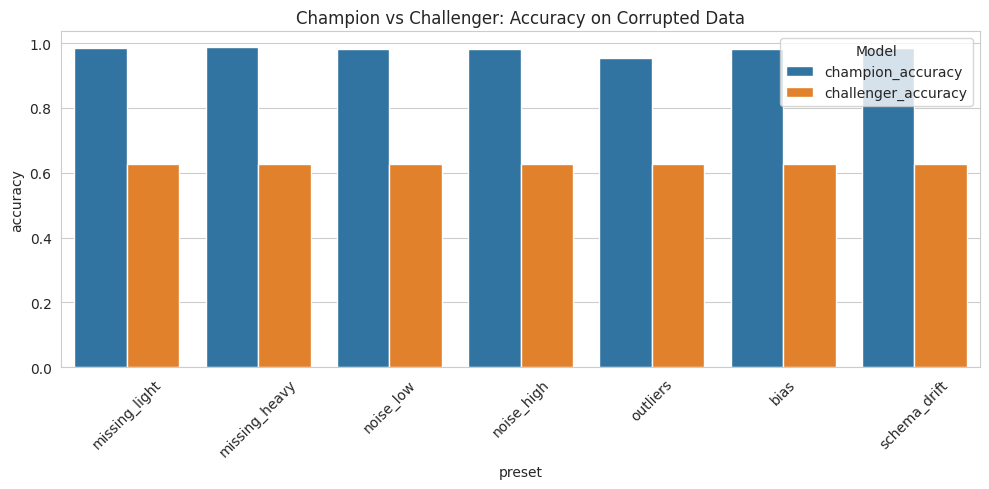

In [19]:
# Compare Champion (Production) vs Challenger (Staging) on all corrupted datasets
champion_model = mlflow.sklearn.load_model(
    model_uri=f"models:/{REGISTERED_MODEL_NAME}/{PRODUCTION_VERSION}"
)
challenger_model = mlflow.sklearn.load_model(
    model_uri=f"models:/{REGISTERED_MODEL_NAME}/{CHALLENGER_VERSION}"
)

comparison_rows = []

for preset, corr_df in corrupted_data.items():
    try:
        # Same preprocessing as monitoring loop
        if "Diagnosis" in corr_df.columns:
            X_corr = corr_df.drop(columns=["Diagnosis"])
            y_corr = corr_df["Diagnosis"]
        elif "diagnosis_label" in corr_df.columns:
            X_corr = corr_df.drop(columns=["diagnosis_label"])
            y_corr = corr_df["diagnosis_label"]
        else:
            continue

        for col in set(FEATURE_NAMES) - set(X_corr.columns):
            X_corr[col] = 0.0
        X_corr = X_corr[FEATURE_NAMES]

        valid = y_corr.notna()
        X_corr = X_corr[valid]
        y_corr = y_corr[valid]
        y_corr = (y_corr > 0.5).astype(int)

        # Scale features for models that require it (e.g., SVM, LR)
        X_corr_scaled = scaler.transform(X_corr[FEATURE_NAMES])
        champ_acc = accuracy_score(y_corr, champion_model.predict(X_corr_scaled))
        chall_acc = accuracy_score(y_corr, challenger_model.predict(X_corr_scaled))

        comparison_rows.append({
            "preset": preset,
            "champion_accuracy": champ_acc,
            "challenger_accuracy": chall_acc,
            "challenger_wins": chall_acc > champ_acc,
        })
    except Exception as e:
        print(f"  {preset}: skipped ({e})")

comp_df = pd.DataFrame(comparison_rows)
display(comp_df.round(4))

# Visual comparison
comp_melted = comp_df.melt(id_vars=["preset"], var_name="model", value_name="accuracy")
comp_melted = comp_melted[comp_melted["model"].isin(["champion_accuracy", "challenger_accuracy"])]

plt.figure(figsize=(10, 5))
sns.barplot(data=comp_melted, x="preset", y="accuracy", hue="model")
plt.title("Champion vs Challenger: Accuracy on Corrupted Data")
plt.xticks(rotation=45)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

In [20]:
# Decision gate: promote challenger if it wins on >50% of presets
wins = comp_df["challenger_wins"].sum()
total = len(comp_df)
print(f"Challenger wins on {wins}/{total} corruption scenarios")

if wins > total / 2:
    print("\n→ Challenger outperforms champion. Promoting to Production...")
    client.transition_model_version_stage(
        name=REGISTERED_MODEL_NAME,
        version=challenger_version,
        stage="Production"
    )
    # Archive old champion
    client.transition_model_version_stage(
        name=REGISTERED_MODEL_NAME,
        version=best_version.version,
        stage="Archived"
    )
    print(f"  Challenger (v{challenger_version}) → Production")
    print(f"  Old champion (v{best_version.version}) → Archived")
else:
    print("\n→ Champion retains Production. Challenger stays in Staging for further evaluation.")

# Final registry state
print("\nFinal registry state:")
versions = client.search_model_versions(f"name='{REGISTERED_MODEL_NAME}'")
for v in sorted(versions, key=lambda x: int(x.version)):
    print(f"  Version {v.version}: stage={v.current_stage}")

Challenger wins on 0/7 corruption scenarios

→ Champion retains Production. Challenger stays in Staging for further evaluation.

Final registry state:
  Version 1: stage=Archived
  Version 2: stage=Archived
  Version 3: stage=Staging
  Version 4: stage=Production
  Version 5: stage=Staging
  Version 6: stage=Archived
  Version 7: stage=Archived
  Version 8: stage=Staging
  Version 9: stage=Production
  Version 10: stage=Staging
  Version 11: stage=Archived
  Version 12: stage=Archived
  Version 13: stage=Staging
  Version 14: stage=Production
  Version 15: stage=Staging


---
## Section 6: Automated Monitoring Loop (Conceptual)

In a real production system, monitoring runs on a schedule (every hour, every batch cycle).
This cell simulates a sequence of "days" where each day brings a different corruption type,
and the monitoring system automatically evaluates the Production model and logs results.

Daily Monitoring Timeline:


,day,preset,accuracy,psi,alert
0,1,missing_light,0.3715,9.7443,True
1,2,noise_low,0.3726,9.7443,True
2,3,noise_high,0.3726,9.7443,True
3,4,outliers,0.3726,9.7443,True
4,5,bias,0.3726,9.7443,True


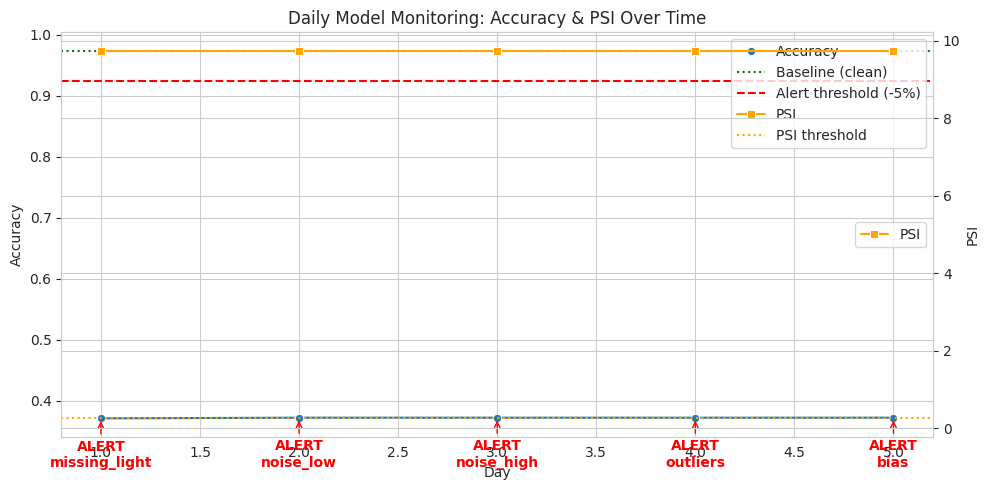

In [21]:
mlflow.set_experiment("breast_cancer_06_daily_monitoring")

daily_presets = ["missing_light", "noise_low", "noise_high", "outliers", "bias"]
timeline = []

for day, preset in enumerate(daily_presets, start=1):
    corr_df = corrupted_data[preset]

    # Simplified preprocessing (assumes Diagnosis exists)
    X_corr = corr_df.drop(columns=["Diagnosis"])
    y_corr = corr_df["Diagnosis"]
    valid = y_corr.notna()
    X_corr = X_corr[valid]
    y_corr = y_corr[valid]
    y_corr = (y_corr > 0.5).astype(int)
    for col in set(FEATURE_NAMES) - set(X_corr.columns):
        X_corr[col] = 0.0
    X_corr = X_corr[FEATURE_NAMES]

    y_pred = champion_model.predict(X_corr)
    proba = champion_model.predict_proba(X_corr)[:, 1]

    acc = accuracy_score(y_corr, y_pred)
    psi = compute_psi(ref_proba, proba)

    with mlflow.start_run(run_name=f"day_{day}") as run:
        mlflow.log_param("day", day)
        mlflow.log_param("preset", preset)
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("accuracy_drop", ref_accuracy - acc)
        mlflow.log_metric("psi", psi)

    timeline.append({"day": day, "preset": preset, "accuracy": acc,
                     "psi": psi, "alert": acc < ref_accuracy - 0.05})

timeline_df = pd.DataFrame(timeline)
print("Daily Monitoring Timeline:")
display(timeline_df.round(4))

fig, ax1 = plt.subplots(figsize=(10, 5))
sns.lineplot(data=timeline_df, x="day", y="accuracy", marker="o", ax=ax1, label="Accuracy")
ax1.axhline(y=ref_accuracy, color="green", linestyle=":", label="Baseline (clean)")
ax1.axhline(y=ref_accuracy - 0.05, color="red", linestyle="--", label="Alert threshold (-5%)")
ax1.set_ylabel("Accuracy")
ax1.set_xlabel("Day")

for _, row in timeline_df.iterrows():
    if row["alert"]:
        ax1.annotate(f"ALERT\n{row['preset']}",
                    xy=(row["day"], row["accuracy"]),
                    xytext=(row["day"], row["accuracy"] - 0.08),
                    ha="center", color="red", fontweight="bold",
                    arrowprops=dict(arrowstyle="->", color="red"))

ax2 = ax1.twinx()
sns.lineplot(data=timeline_df, x="day", y="psi", marker="s", ax=ax2,
             color="orange", label="PSI")
ax2.set_ylabel("PSI")
ax2.axhline(y=0.25, color="orange", linestyle=":", label="PSI threshold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title("Daily Model Monitoring: Accuracy & PSI Over Time")
plt.tight_layout()
plt.show()

---
## Summary

In this notebook you learned:

1. **MlflowClient API**: Query experiments, extract runs, compare programmatically
2. **Model Registry**: Register models, assign versions, transition through stages
3. **Drift Monitoring**: PSI, KS-test, accuracy drop — and how to interpret thresholds
4. **Schema Drift**: Detecting column mismatches at inference time
5. **Champion/Challenger**: Systematic model comparison and promotion decisions
6. **Automated Monitoring**: Scheduled evaluation loops with alerting

These are the core building blocks of a production MLOps pipeline.

---
## Exercises

1. **Alerting System**: Define a function `check_alerts(monitoring_df, acc_threshold=0.05, psi_threshold=0.25)`
   that returns a list of triggered alerts. How many presets trigger each alert type?

2. **Multi-Model Monitoring**: Register each of the 4 models as separate registered model names
   (e.g. `breast_cancer_lr`, `breast_cancer_xgb`). Compare which is most robust to drift
   across all 7 corruption types.

3. **Feature Importance Drift**: For the champion and challenger models (tree-based), extract
   feature importances. Are the top-5 features the same? What does it imply if they differ?

4. **Custom Corruption**: Add a new preset to `data_injection/config.py` that simulates
   seasonal drift (e.g., only affects a specific feature group). Regenerate corrupted data,
   re-run monitoring, and observe PSI.

5. **Auto-Retraining**: Implement a function that: monitors → detects drift → auto-retrains
   a new model → registers it → runs the champion/challenger comparison → promotes if better.
   This is the foundation of a self-healing ML pipeline.